<a href="https://colab.research.google.com/github/fifanuurunhalizah09/PCVK_Ganjil2026/blob/main/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

 Mengubah tingkat kecerahan citra 
----------------------------------
Masukkan nilai kecerahan: 30


/tmp/ipykernel_2746/2432563730.py:17: RuntimeWarning: overflow encountered in scalar add
  brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)


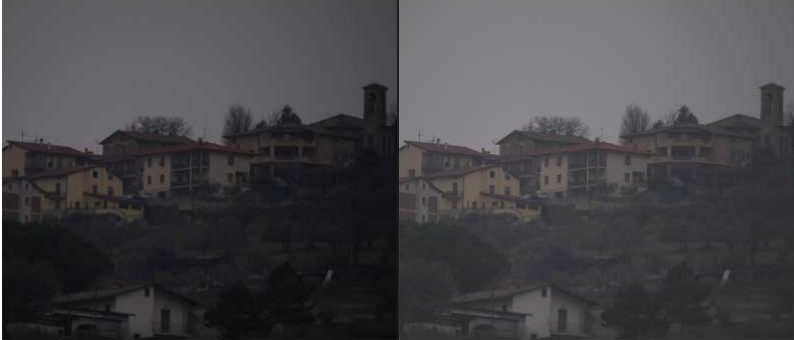

In [ ]:
print(' Mengubah tingkat kecerahan citra ')
print('----------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

#sesuaikan dengan file dan folder di drive Anda
original = cv.imread('/content/drive/MyDrive/PCVK 2026/houses.jpg')
brightness_image = np.zeros(original.shape, original.dtype)

#akses per piksel
#np.clip digunakan untuk melakukan truncate pixel (nilai dibatasi antara 0-255)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

#cara simple tanpa for loop
#brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

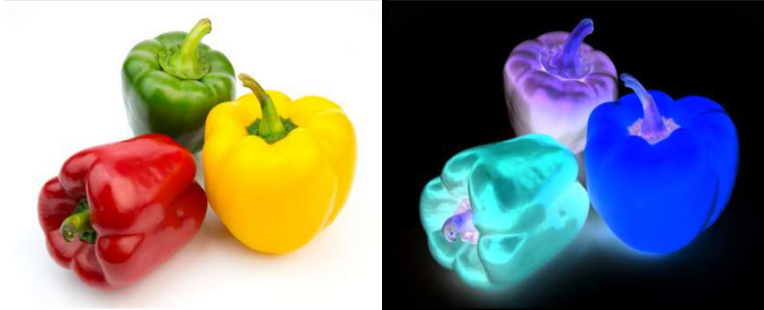

In [ ]:
original = cv.imread('/content/drive/MyDrive/PCVK 2026/peppers.jpg')

inverse = 255 - original

final_frame = cv.hconcat((original, inverse))
cv2_imshow(final_frame)

Mengubah tingkat kontras dan kecerahan citra
--------------------------------------------
Masukkan tingkat kecerahan: 10
Masukkan kontras: 1.5


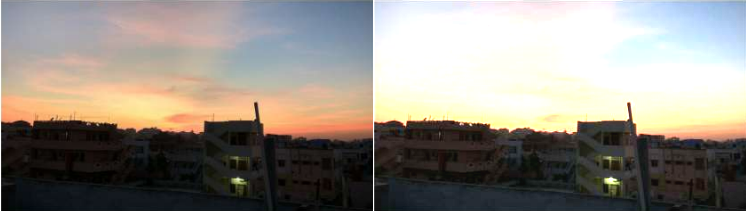

In [ ]:
print('Mengubah tingkat kontras dan kecerahan citra')
print('--------------------------------------------')

try:
    brightness = int(input('Masukkan tingkat kecerahan: '))
    contrast = float(input('Masukkan kontras: '))
except ValueError:
    print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK 2026/sunset.jpg')
contrast_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            contrast_image[y,x,c] = np.clip(
                contrast * original[y,x,c] + brightness,
                0, 255
            )

final_frame = cv.hconcat((original, contrast_image))
cv2_imshow(final_frame)

Mengubah tingkat kecerahan citra dengan Transformasi Log
--------------------------------------------------------
Masukkan nilai kecerahan: 50


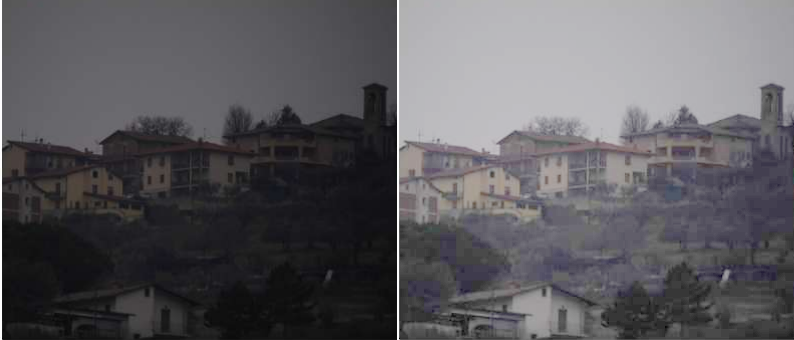

In [ ]:
print('Mengubah tingkat kecerahan citra dengan Transformasi Log')
print('--------------------------------------------------------')

try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

# Membaca gambar
original = cv.imread('/content/drive/MyDrive/PCVK 2026/houses.jpg')

if original is None:
    print('Gambar tidak ditemukan. Periksa kembali lokasi dan nama file.')
else:
    # Mengubah gambar ke float
    image_float = original.astype(float)

    # Rumus transformasi logaritmik
    c = brightness
    log_image = c * np.log(1 + image_float)

    # Normalisasi agar nilai berada pada 0-255
    log_image = cv.normalize(log_image, None, 0, 255, cv.NORM_MINMAX)

    # Mengubah kembali ke uint8
    log_image = log_image.astype(np.uint8)

    # Menggabungkan gambar asli dan hasil transformasi
    final_frame = cv.hconcat([original, log_image])

    # Menampilkan hasil
    cv2_imshow(final_frame)

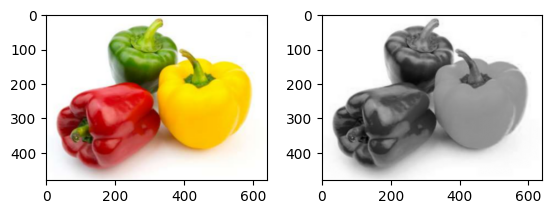

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Membaca gambar
original = cv.imread('/content/drive/MyDrive/PCVK 2026/peppers.jpg')

# Crop gambar agar ukuran peppers mendekati modul
original = original[10:470, 20:620]

# Resize
original = cv.resize(original, (640, 480))

# Averaging
averaging = np.zeros(original.shape[:2], dtype=np.uint8)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        b = int(original[y, x, 0])
        g = int(original[y, x, 1])
        r = int(original[y, x, 2])

        averaging[y, x] = (r + g + b) // 3

# BGR ke RGB
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

# Tampilan
plt.figure(figsize=(6.4, 4.8))

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.xticks([0, 200, 400, 600])
plt.yticks([0, 100, 200, 300, 400])

plt.subplot(1, 2, 2)
plt.imshow(averaging, cmap='gray')
plt.xticks([0, 200, 400, 600])
plt.yticks([0, 100, 200, 300, 400])

plt.subplots_adjust(wspace=0.25)
plt.show()

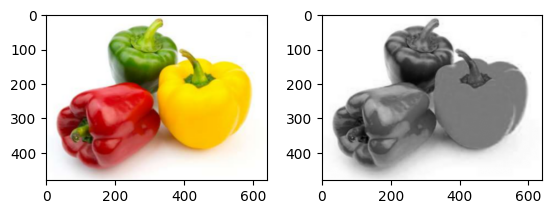

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Membaca gambar
original = cv.imread('/content/drive/MyDrive/PCVK 2026/peppers.jpg')

# Crop dan resize agar sesuai dengan modul
original = original[10:470, 20:620]
original = cv.resize(original, (640, 480))

# Lightness
lightness = np.zeros(original.shape[:2], dtype=np.uint8)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        b = int(original[y, x, 0])
        g = int(original[y, x, 1])
        r = int(original[y, x, 2])

        lightness[y, x] = (max(r, g, b) + min(r, g, b)) // 2

# BGR ke RGB
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

# Menampilkan hasil
plt.figure(figsize=(6.4, 4.8))

# Gambar asli
plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.xticks([0, 200, 400, 600])
plt.yticks([0, 100, 200, 300, 400])

# Hasil Lightness
plt.subplot(1, 2, 2)
plt.imshow(lightness, cmap='gray')
plt.xticks([0, 200, 400, 600])
plt.yticks([0, 100, 200, 300, 400])

plt.subplots_adjust(wspace=0.25)
plt.show()

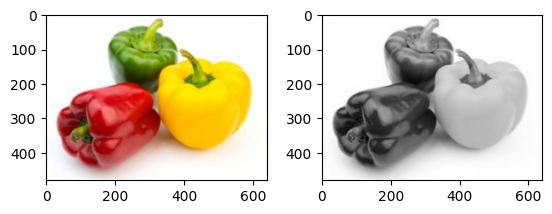

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Membaca gambar
original = cv.imread('/content/drive/MyDrive/PCVK 2026/peppers.jpg')

# Crop dan resize agar sesuai dengan modul
original = original[10:470, 20:620]
original = cv.resize(original, (640, 480))

# Luminance
luminance = np.zeros(original.shape[:2], dtype=np.uint8)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        b = int(original[y, x, 0])
        g = int(original[y, x, 1])
        r = int(original[y, x, 2])

        luminance[y, x] = np.clip(
            0.299 * r + 0.587 * g + 0.114 * b,
            0, 255
        )

# BGR ke RGB
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

# Menampilkan hasil
plt.figure(figsize=(6.4, 4.8))

# Gambar asli
plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.xticks([0, 200, 400, 600])
plt.yticks([0, 100, 200, 300, 400])

# Hasil Luminance
plt.subplot(1, 2, 2)
plt.imshow(luminance, cmap='gray')
plt.xticks([0, 200, 400, 600])
plt.yticks([0, 100, 200, 300, 400])

plt.subplots_adjust(wspace=0.25)
plt.show()

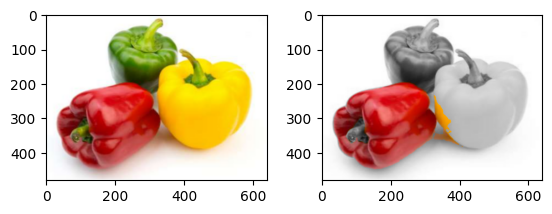

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Membaca gambar
original = cv.imread('/content/drive/MyDrive/PCVK 2026/peppers.jpg')

# Crop dan resize
original = original[10:470, 20:620]
original = cv.resize(original, (640, 480))

# Membuat grayscale
gray = cv.cvtColor(original, cv.COLOR_BGR2GRAY)

# Membuat hasil grayscale 3 channel
result = cv.cvtColor(gray, cv.COLOR_GRAY2BGR)

# Menentukan warna merah
for y in range(original.shape[0]):
    for x in range(original.shape[1]):

        b = int(original[y, x, 0])
        g = int(original[y, x, 1])
        r = int(original[y, x, 2])

        # Warna merah tetap berwarna
        if r > 1.5 * g and r > 1.5 * b:
            result[y, x] = original[y, x]

# Mengubah BGR ke RGB
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)
result_rgb = cv.cvtColor(result, cv.COLOR_BGR2RGB)

# Menampilkan hasil
plt.figure(figsize=(6.4, 4.8))

# Gambar asli
plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.xticks([0, 200, 400, 600])
plt.yticks([0, 100, 200, 300, 400])

# Hasil
plt.subplot(1, 2, 2)
plt.imshow(result_rgb)
plt.xticks([0, 200, 400, 600])
plt.yticks([0, 100, 200, 300, 400])

plt.subplots_adjust(wspace=0.25)
plt.show()

Gamma Correction pada citra
---------------------------
Masukkan nilai Gamma: 0.5


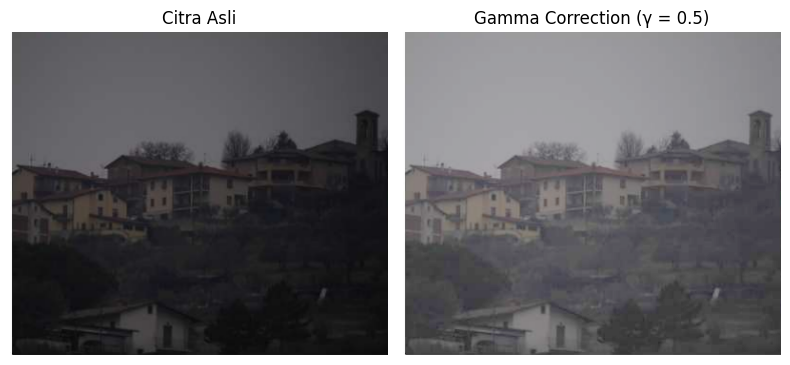

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

print('Gamma Correction pada citra')
print('---------------------------')

try:
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')

# Membaca gambar
original = cv.imread('/content/drive/MyDrive/PCVK 2026/houses.jpg')

# Gamma Correction
gamma_image = np.zeros(original.shape, dtype=np.uint8)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            gamma_image[y, x, c] = np.clip(
                255 * (original[y, x, c] / 255) ** gamma,
                0, 255
            )

# Mengubah BGR menjadi RGB
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)
gamma_rgb = cv.cvtColor(gamma_image, cv.COLOR_BGR2RGB)

# Menampilkan hasil
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gamma_rgb)
plt.title('Gamma Correction (γ = ' + str(gamma) + ')')
plt.axis('off')

plt.tight_layout()
plt.show()

Masukkan nilai bit depth (1-8): 3
Bit depth awal: 8 bit
Bit depth tujuan: 3 bit
Jumlah level: 8


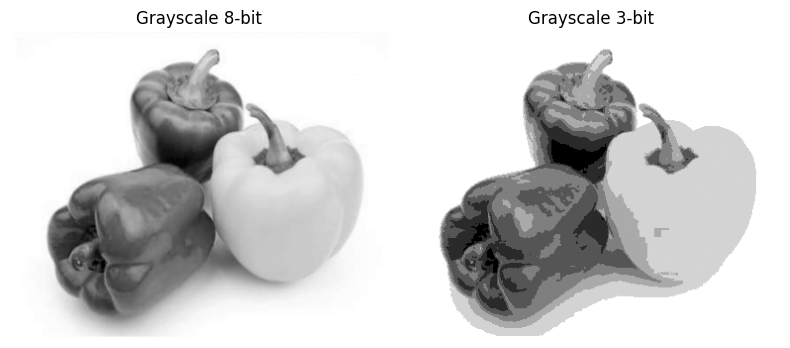

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Bit depth awal
bit_depth_awal = 8

# Memasukkan bit depth tujuan
bit_depth = int(input('Masukkan nilai bit depth (1-8): '))

# Menghitung jumlah level
jumlah_level = 2 ** bit_depth

print('Bit depth awal:', bit_depth_awal, 'bit')
print('Bit depth tujuan:', bit_depth, 'bit')
print('Jumlah level:', jumlah_level)

# Membaca gambar grayscale
original = cv.imread(
    '/content/drive/MyDrive/PCVK 2026/peppers.jpg',
    cv.IMREAD_GRAYSCALE
)

# Menghitung interval level
level = 255 / (jumlah_level - 1)

# Membuat gambar hasil
depth_image = np.zeros(original.shape, original.dtype)

# Proses quantisasi
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        depth_image[y, x] = round(original[y, x] / level) * level

# Menampilkan hasil
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(original, cmap='gray')
plt.title('Grayscale 8-bit')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(depth_image, cmap='gray')
plt.title('Grayscale ' + str(bit_depth) + '-bit')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import cv2 as cv
import numpy as np
import os

original = cv.imread('/content/drive/MyDrive/PCVK 2026/galaxy.jpg')

noise_folder = '/content/drive/MyDrive/PCVK 2026/noises'
os.makedirs(noise_folder, exist_ok=True)

for i in range(100):
    noise = np.random.normal(0, 25, original.shape)
    noisy_image = original.astype(np.float32) + noise
    noisy_image = np.clip(noisy_image, 0, 255).astype(np.uint8)

    cv.imwrite(
        f'{noise_folder}/noise_{i+1:03d}.jpg',
        noisy_image
    )

print('100 citra Gaussian Noise berhasil dibuat.')

100 citra Gaussian Noise berhasil dibuat.


In [ ]:
import glob

cv_img = []

for img in glob.glob('/content/drive/MyDrive/PCVK 2026/noises/*.jpg'):
    n = cv.imread(img)
    cv_img.append(n)

print('Jumlah citra:', len(cv_img))

Jumlah citra: 100


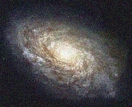

In [ ]:
average_10 = np.mean(cv_img[:10], axis=0)
average_10 = np.clip(average_10, 0, 255).astype(np.uint8)

cv2_imshow(average_10)

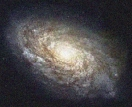

In [ ]:
average_20 = np.mean(cv_img[:20], axis=0)
average_20 = np.clip(average_20, 0, 255).astype(np.uint8)

cv2_imshow(average_20)

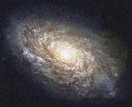

In [ ]:
average_40 = np.mean(cv_img[:40], axis=0)
average_40 = np.clip(average_40, 0, 255).astype(np.uint8)

cv2_imshow(average_40)

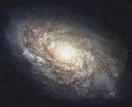

In [ ]:
average_80 = np.mean(cv_img[:80], axis=0)
average_80 = np.clip(average_80, 0, 255).astype(np.uint8)

cv2_imshow(average_80)

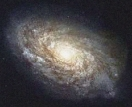

In [ ]:
average_100 = np.mean(cv_img[:100], axis=0)
average_100 = np.clip(average_100, 0, 255).astype(np.uint8)

cv2_imshow(average_100)

In [ ]:
from math import log10, sqrt

def PSNR(img1, img2):
    mse = np.mean((img1.astype(np.float32) - img2.astype(np.float32)) ** 2)

    if mse == 0:
        return 100

    max_pixel = 255.0
    psnr = 20 * log10(max_pixel / sqrt(mse))

    return psnr

In [ ]:
original = cv.imread('/content/drive/MyDrive/PCVK 2026/galaxy.jpg')

psnr_10 = PSNR(original, average_10)
psnr_20 = PSNR(original, average_20)
psnr_40 = PSNR(original, average_40)
psnr_80 = PSNR(original, average_80)
psnr_100 = PSNR(original, average_100)

print('PSNR Average 10  :', psnr_10, 'dB')
print('PSNR Average 20  :', psnr_20, 'dB')
print('PSNR Average 40  :', psnr_40, 'dB')
print('PSNR Average 80  :', psnr_80, 'dB')
print('PSNR Average 100 :', psnr_100, 'dB')

PSNR Average 10  : 33.300000711424765 dB
PSNR Average 20  : 36.04597490446302 dB
PSNR Average 40  : 38.70395764649221 dB
PSNR Average 80  : 41.05327750364478 dB
PSNR Average 100 : 41.70651046026151 dB


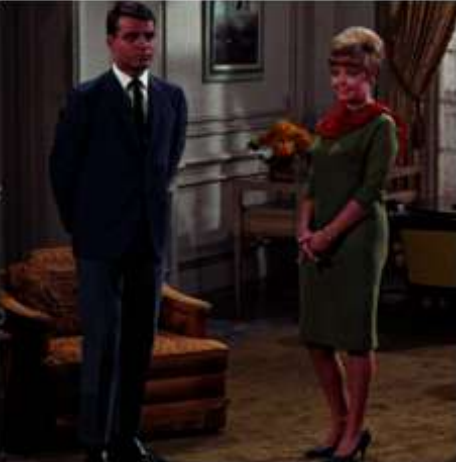

In [ ]:
couple = cv.imread('/content/drive/MyDrive/PCVK 2026/couple.tiff')

cv2_imshow(couple)

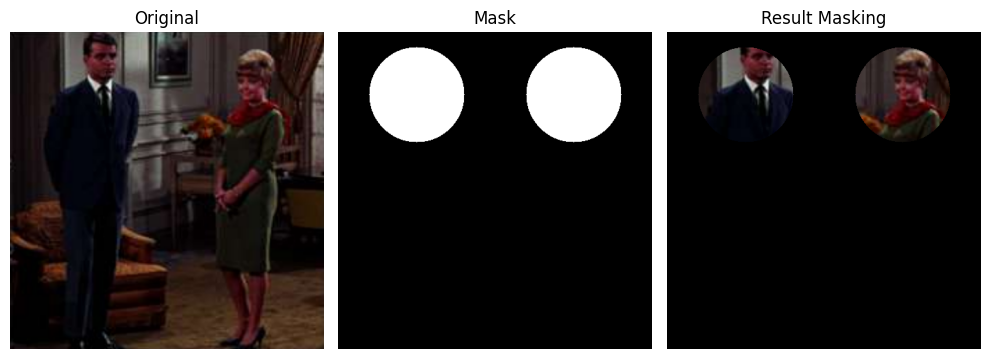

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Baca gambar asli
img = cv2.imread('/content/drive/MyDrive/PCVK 2026/couple.tiff')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w, _ = img.shape

# 2. Buat mask (2 lingkaran putih pada background hitam)
mask = np.zeros((h, w), dtype=np.uint8)
cv2.circle(mask, (int(w*0.25), int(h*0.2)), int(h*0.15), 255, -1)  # Lingkaran kiri
cv2.circle(mask, (int(w*0.75), int(h*0.2)), int(h*0.15), 255, -1)  # Lingkaran kanan

# 3. Proses Result Masking (Bitwise AND)
result_masking = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)

# 4. Tampilkan hasil
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap='gray')
plt.title('Mask')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(result_masking)
plt.title('Result Masking')
plt.axis('off')

plt.tight_layout()
plt.show()

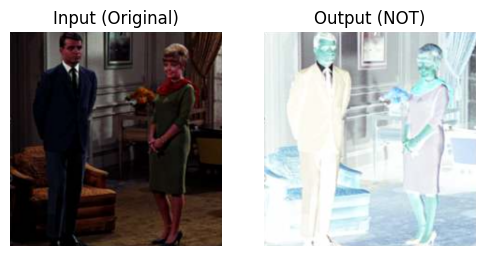

In [ ]:
# Operator NOT
op_not = cv2.bitwise_not(img_rgb)

# Tampilkan Hasil
plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Input (Original)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(op_not)
plt.title('Output (NOT)')
plt.axis('off')

plt.show()

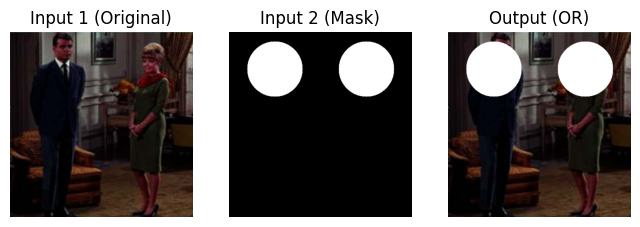

In [ ]:
# Ubah mask jadi 3 channel agar sesuai dengan gambar RGB
mask_3ch = cv2.cvtColor(mask, cv2.COLOR_GRAY2RGB)

# Operator OR
op_or = cv2.bitwise_or(img_rgb, mask_3ch)

# Tampilkan Hasil
plt.figure(figsize=(8, 3))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title('Input 1 (Original)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mask_3ch)
plt.title('Input 2 (Mask)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(op_or)
plt.title('Output (OR)')
plt.axis('off')

plt.show()

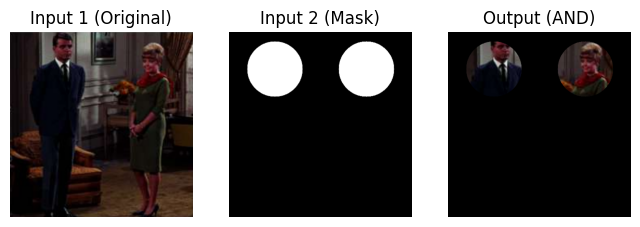

In [ ]:
# Operator AND
op_and = cv2.bitwise_and(img_rgb, mask_3ch)

# Tampilkan Hasil
plt.figure(figsize=(8, 3))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title('Input 1 (Original)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mask_3ch)
plt.title('Input 2 (Mask)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(op_and)
plt.title('Output (AND)')
plt.axis('off')

plt.show()

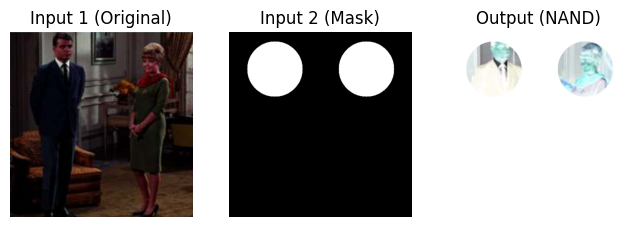

In [ ]:
# Operator NAND (Inversi dari hasil AND)
op_nand = cv2.bitwise_not(op_and)

# Tampilkan Hasil
plt.figure(figsize=(8, 3))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title('Input 1 (Original)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mask_3ch)
plt.title('Input 2 (Mask)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(op_nand)
plt.title('Output (NAND)')
plt.axis('off')

plt.show()

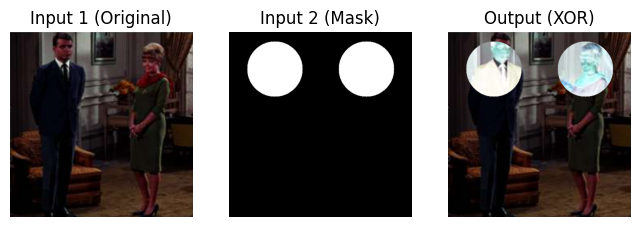

In [ ]:
# Operator XOR
op_xor = cv2.bitwise_xor(img_rgb, mask_3ch)

# Tampilkan Hasil
plt.figure(figsize=(8, 3))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title('Input 1 (Original)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mask_3ch)
plt.title('Input 2 (Mask)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(op_xor)
plt.title('Output (XOR)')
plt.axis('off')

plt.show()

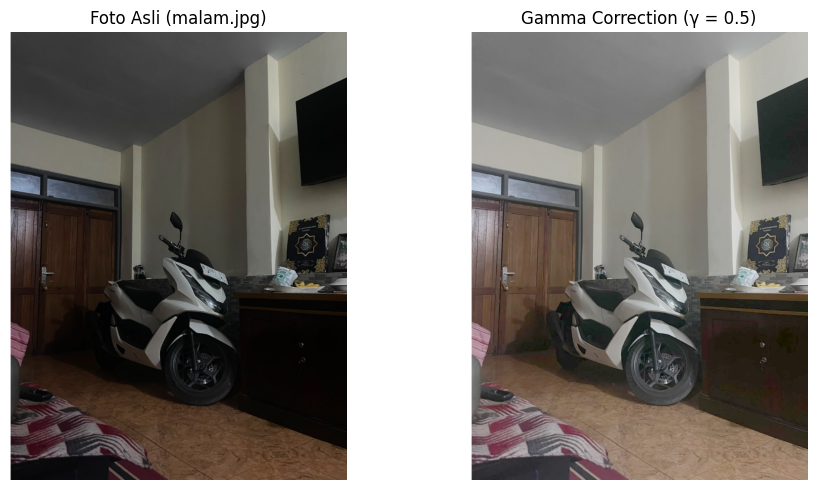

In [93]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Baca citra malam hari dari Google Drive
img_path = '/content/drive/MyDrive/PCVK 2026/malam.jpg'
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 2. Penerapan Metode Gamma Correction
gamma = 0.5  # Nilai gamma < 1 untuk menerangkan area gelap

# Buat Lookup Table (LUT) langsung dengan pangkat gamma
table = np.array([((i / 255.0) ** gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")

# Terapkan Gamma Correction menggunakan LUT
result_gamma = cv2.LUT(img_rgb, table)

# 3. Tampilkan Perbandingan Citra Asli dan Hasil
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Foto Asli (malam.jpg)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(result_gamma)
plt.title(f'Gamma Correction (\u03b3 = {gamma})')
plt.axis('off')

plt.tight_layout()
plt.show()

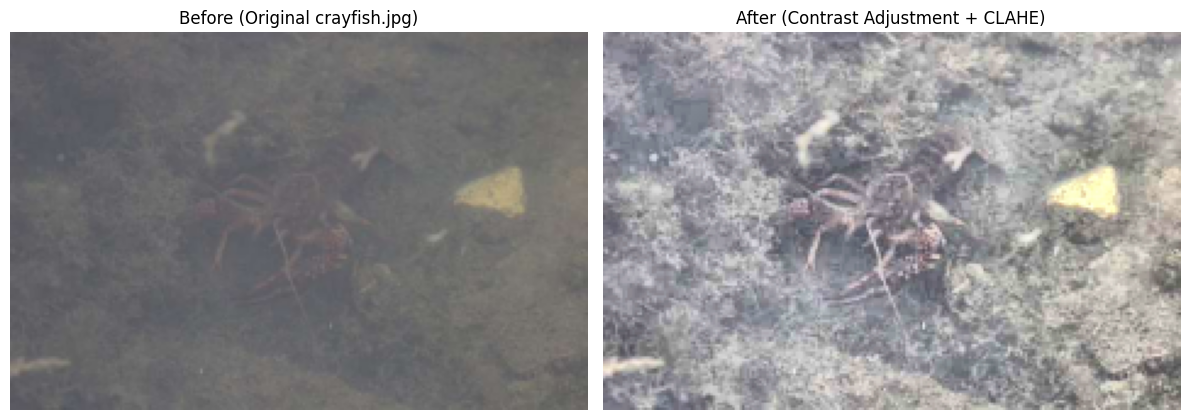

In [94]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Baca gambar crayfish.jpg
img_path = '/content/drive/MyDrive/PCVK 2026/crayfish.jpg'
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 2. Metode 1: Kombinasi Penyesuaian Kontras/Brightness Linier + CLAHE
# A. Penyesuaian Contrast & Brightness (α = 1.8, β = -30)
alpha = 1.8  # Pengali Kontras
beta = -30   # Bias Brightness
adjusted = cv2.convertScaleAbs(img_rgb, alpha=alpha, beta=beta)

# B. Penerapan CLAHE (Contrast Limited Adaptive Histogram Equalization) pada Channel L (Lab Color Space)
lab = cv2.cvtColor(adjusted, cv2.COLOR_RGB2LAB)
l, a, b = cv2.split(lab)

# Buat objek CLAHE
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
cl = clahe.apply(l)

# Gabungkan kembali channel dan konversi ke RGB
limg = cv2.merge((cl, a, b))
result = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)

# 3. Menampilkan Hasil Before - After
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Before (Original crayfish.jpg)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(result)
plt.title('After (Contrast Adjustment + CLAHE)')
plt.axis('off')

plt.tight_layout()
plt.show()